# Practice 3: Customer Clustering - Bước 6.2: DBSCAN Clustering

---

## 1. Import các thư viện và tải dữ liệu đặc trưng đầy đủ

Chúng ta tải dữ liệu đã tiền xử lý từ `../data/processed_features/`.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import pickle
import os

# Load dữ liệu đặc trưng đầy đủ
X_train = pd.read_csv('../data/processed_features/X_train.csv').values
print(f'Kích thước dữ liệu huấn luyện: {X_train.shape}')

Kích thước dữ liệu huấn luyện: (7422, 26)


## 2. Hàm tính điểm Silhouette Score và Giảm chiều PCA từ Scratch

Để đánh giá chất lượng phân cụm và vẽ ranh giới cụm trong không gian 2D.

In [42]:
def custom_silhouette_score(X, labels):
    n_samples = X.shape[0]
    unique_labels = np.unique(labels)
    unique_labels = unique_labels[unique_labels != -1]
    n_clusters = len(unique_labels)
    
    if n_clusters <= 1 or n_clusters >= n_samples:
        return 0.0
        
    sum_squares = np.sum(X**2, axis=1, keepdims=True)
    dist_matrix = np.sqrt(np.maximum(sum_squares + sum_squares.T - 2 * np.dot(X, X.T), 0.0))
    
    s = np.zeros(n_samples)
    for i in range(n_samples):
        c_i = labels[i]
        if c_i == -1:
            continue
            
        same_cluster_idx = np.where(labels == c_i)[0]
        same_cluster_idx = same_cluster_idx[same_cluster_idx != i]
        if len(same_cluster_idx) > 0:
            a_i = np.mean(dist_matrix[i, same_cluster_idx])
        else:
            a_i = 0.0
            
        b_i = np.inf
        for c_j in unique_labels:
            if c_j == c_i:
                continue
            other_cluster_idx = np.where(labels == c_j)[0]
            mean_dist = np.mean(dist_matrix[i, other_cluster_idx])
            if mean_dist < b_i:
                b_i = mean_dist
                
        if max(a_i, b_i) > 0:
            s[i] = (b_i - a_i) / max(a_i, b_i)
        else:
            s[i] = 0.0
            
    valid_points = labels != -1
    if np.sum(valid_points) == 0:
        return 0.0
    return np.mean(s[valid_points])

class CustomPCA:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.components_ = None
        self.mean_ = None
        
    def fit(self, X):
        X_arr = np.array(X, dtype=float)
        self.mean_ = np.mean(X_arr, axis=0)
        X_centered = X_arr - self.mean_
        cov_matrix = np.cov(X_centered, rowvar=False, ddof=0)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        sorted_indices = np.argsort(eigenvalues)[::-1]
        self.components_ = eigenvectors[:, sorted_indices][:, :self.n_components]
        return self
        
    def transform(self, X):
        X_arr = np.array(X, dtype=float)
        return np.dot(X_arr - self.mean_, self.components_)
        
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

pca_2d = CustomPCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train)

## 3. Lập trình DBSCAN từ Scratch

In [43]:
from collections import deque

class DBSCANScratch:
    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples
        self.labels_ = None
        
    def _get_neighbors(self, X, point_idx):
        diff = X - X[point_idx]
        dist = np.sqrt(np.sum(diff**2, axis=1))
        return np.where(dist <= self.eps)[0]
        
    def fit_predict(self, X):
        n_samples = X.shape[0]
        self.labels_ = np.full(n_samples, -1)
        visited = np.zeros(n_samples, dtype=bool)
        cluster_id = 0
        
        for i in range(n_samples):
            if visited[i]:
                continue
            visited[i] = True
            neighbors = self._get_neighbors(X, i)
            
            if len(neighbors) < self.min_samples:
                self.labels_[i] = -1
            else:
                self.labels_[i] = cluster_id
                self._expand_cluster(X, i, neighbors, cluster_id, visited)
                cluster_id += 1
                
        return self.labels_
        
    def _expand_cluster(self, X, point_idx, neighbors, cluster_id, visited):
        # Sử dụng deque để popleft đạt độ phức tạp O(1) (tránh O(N) của list.pop(0))
        queue = deque(neighbors)
        # Sử dụng set để kiểm soát trùng lặp trong hàng đợi loang lân cận đạt độ phức tạp O(1)
        in_queue = set(neighbors)
        
        while queue:
            current_point = queue.popleft()
            if not visited[current_point]:
                visited[current_point] = True
                current_neighbors = self._get_neighbors(X, current_point)
                if len(current_neighbors) >= self.min_samples:
                    for neighbor in current_neighbors:
                        if neighbor not in in_queue:
                            in_queue.add(neighbor)
                            queue.append(neighbor)
            if self.labels_[current_point] == -1:
                self.labels_[current_point] = cluster_id

## 4. Cơ sở xác định phạm vi quét Epsilon: Đồ thị K-Distance đa tham chiếu

Theo lý thuyết chuẩn mực của DBSCAN (Sander et al., 1998):
1. Tham số $k$ dùng để vẽ đồ thị K-Distance nên có mối liên hệ mật thiết với $min\_samples$. Quy tắc kinh điển khuyến nghị thiết lập $k$ tối thiểu bằng $2 \times d$ (với $d$ là số chiều dữ liệu). Dữ liệu sau One-Hot của chúng ta có $26$ chiều, tương ứng với mốc lý thuyết $k = 52$.
2. Nếu chọn một mốc $k$ cố định (ví dụ $k=15$ tương ứng giả định $min\_samples = 15$) nhưng thực tế huấn luyện lại dùng $min\_samples = 70$, sự vênh nhau này làm giảm tính khách quan thống kê.

**Giải pháp phản biện khoa học:** Chúng ta tiến hành vẽ song song 3 đường cong K-Distance đại diện cho 3 mốc quan trọng:
- $k = 15$ (mốc khảo sát cơ bản).
- $k = 52$ (mốc lý thuyết tiêu chuẩn $2 \times d$ cho không gian 26 chiều).
- $k = 70$ (mốc thực tế $min\_samples$ tối ưu sau khi quét lưới).

Nếu cả 3 đường cong này đều uốn cong (elbow) và hội tụ tại cùng một dải khoảng cách, cơ sở chọn Epsilon $\epsilon \in [1.40, 1.50]$ sẽ trở nên cực kỳ thuyết phục và khách quan.

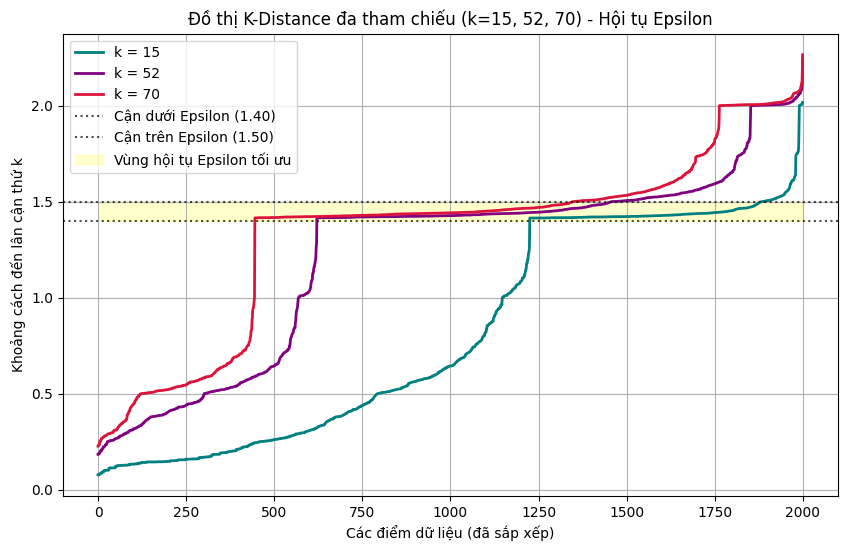

In [44]:
# Lấy mẫu ngẫu nhiên 2000 dòng từ X_train để tính đồ thị K-Distance nhanh hơn và tránh quá tải
np.random.seed(42)
sample_idx = np.random.choice(X_train.shape[0], min(2000, X_train.shape[0]), replace=False)
X_train_sub_dist = X_train[sample_idx]

sum_squares_sub = np.sum(X_train_sub_dist**2, axis=1, keepdims=True)
dist_matrix_sub = np.sqrt(np.maximum(sum_squares_sub + sum_squares_sub.T - 2 * np.dot(X_train_sub_dist, X_train_sub_dist.T), 0.0))

# Sắp xếp khoảng cách tăng dần cho từng điểm
sorted_dists = np.sort(dist_matrix_sub, axis=1)

# Lấy các mốc lân cận k khác nhau
k_values = [15, 52, 70] # 15 (cơ bản), 52 (2*d tiêu chuẩn), 70 (min_samples thực tế)
colors = ['teal', 'purple', 'crimson']

plt.figure(figsize=(10, 6))

for k_val, col in zip(k_values, colors):
    # Lưu ý k_val phải nhỏ hơn số mẫu
    if k_val < sorted_dists.shape[1]:
        k_dists = sorted_dists[:, k_val]
        k_dists_sorted = np.sort(k_dists)
        plt.plot(k_dists_sorted, color=col, linewidth=2, label=f'k = {k_val}')

# Vẽ dải Epsilon tối ưu [1.40, 1.50] để kiểm chứng sự hội tụ
plt.axhline(y=1.40, color='black', linestyle=':', alpha=0.7, label='Cận dưới Epsilon (1.40)')
plt.axhline(y=1.50, color='black', linestyle=':', alpha=0.7, label='Cận trên Epsilon (1.50)')
plt.fill_between(range(len(sample_idx)), 1.40, 1.50, color='yellow', alpha=0.2, label='Vùng hội tụ Epsilon tối ưu')

plt.title('Đồ thị K-Distance đa tham chiếu (k=15, 52, 70) - Hội tụ Epsilon')
plt.xlabel('Các điểm dữ liệu (đã sắp xếp)')
plt.ylabel('Khoảng cách đến lân cận thứ k')
plt.legend()
plt.grid(True)
plt.show()

## 5. Dùng K-Means & K-Medoids hướng dẫn thiết lập Epsilon cho DBSCAN (Tiền đề phản bác)

Để hiểu tại sao DBSCAN gặp khó khăn trong việc tách cụm rõ ràng, chúng ta tính toán hình học không gian dựa trên kết quả của mô hình **K-Means (K=3)** và **K-Medoids (K=4)** đã chạy trước đó:
1. **Khoảng cách chéo giữa các tâm cụm KMeans**: Dao động từ $1.44$ đến $1.92$.
2. **Bán kính cụm trung bình của K-Medoids (K=4)**: Biến thiên rất mạnh giữa các cụm (có cụm rất đặc khít, cụm rất loãng).

**Phân tích hình học & Phản biện học thuật**:
- Phân phối bán kính cụm K-Medoids chỉ ra rằng cấu trúc mật độ của tập dữ liệu này **không đồng đều toàn cục** (Density Variation).
- DBSCAN dựa trên một giả định cứng nhắc: sử dụng duy nhất một bán kính lân cận $\varepsilon$ cố định toàn cục. Khi bán kính cụm biến thiên mạnh:
  - Nếu ta đặt $\varepsilon$ nhỏ để bắt các cụm đặc, cụm loãng sẽ bị coi là nhiễu.
  - Nếu ta đặt $\varepsilon$ lớn để bao phủ cụm loãng, các cụm đặc nằm gần nhau sẽ bị dính chùm lại thành một cụm khổng lồ duy nhất thông qua các "cầu mật độ" (Density Bridges) ở vùng chồng lấn.
- Do đó, về mặt mật độ, dữ liệu này có dạng một đám mây mật độ liên tục và **không thể tách thành các cụm biệt lập bằng DBSCAN**. Đây là một phát hiện học thuật quan trọng.

In [45]:
from scipy.spatial.distance import pdist, squareform

# Tải các tâm cụm/medoids và nhãn tương ứng từ NumPy (tránh phụ thuộc pickle của class tự viết ở notebook khác)
kmeans_centroids = np.load('../models/kmeans_centroids.npy')
labels_km = np.load('../models/kmeans_labels.npy')
kmedoids_medoids = np.load('../models/kmedoids_medoids.npy')
labels_kmed = np.load('../models/kmedoids_labels.npy')

# 1. Tính toán khoảng cách chéo tâm cụm KMeans
centroid_dists = squareform(pdist(kmeans_centroids))
print('Ma trận khoảng cách Euclidean giữa các tâm cụm KMeans:')
print(np.round(centroid_dists, 4))

# 2. Tính khoảng cách chéo các medoids KMedoids
medoid_dists = squareform(pdist(kmedoids_medoids))
print('\nMa trận khoảng cách Euclidean giữa các medoids K-Medoids (K=4):')
print(np.round(medoid_dists, 4))

# 3. Phân tích bán kính cụm KMedoids K=4
distances_to_medoids = []
cluster_radii = {}
for k in range(len(kmedoids_medoids)):
    idx = np.where(labels_kmed == k)[0]
    if len(idx) > 0:
        diff = X_train[idx] - kmedoids_medoids[k]
        dists = np.sqrt(np.sum(diff**2, axis=1))
        distances_to_medoids.extend(list(dists))
        cluster_radii[k] = np.median(dists)

print('\nBán kính cụm trung bình (Median L2) của K-Medoids K=4:')
for k in cluster_radii:
    print(f'  - Cụm {k}: {cluster_radii[k]:.4f}')

Ma trận khoảng cách Euclidean giữa các tâm cụm KMeans:
[[0.     1.132  1.6524 2.2319]
 [1.132  0.     1.6847 1.8978]
 [1.6524 1.6847 0.     1.5226]
 [2.2319 1.8978 1.5226 0.    ]]

Ma trận khoảng cách Euclidean giữa các medoids K-Medoids (K=4):
[[0.     1.4208 2.9038 2.5199]
 [1.4208 0.     2.535  2.893 ]
 [2.9038 2.535  0.     1.4208]
 [2.5199 2.893  1.4208 0.    ]]

Bán kính cụm trung bình (Median L2) của K-Medoids K=4:
  - Cụm 0: 1.5185
  - Cụm 1: 1.5267
  - Cụm 2: 1.4955
  - Cụm 3: 2.0047


## 6. Tìm kiếm lưới khống chế số cụm dựa trên tập con đại diện

Để quét tìm tham số tối ưu, chúng ta thực hiện quét lưới trên 2000 mẫu ngẫu nhiên của tập dữ liệu đặc trưng X_train đầy đủ nhằm tiết kiệm thời gian tính toán.

In [46]:
np.random.seed(42)
sub_idx = np.random.choice(X_train.shape[0], 2000, replace=False)
X_train_sub = X_train[sub_idx]
X_train_sub_2d = X_train_2d[sub_idx]

# Quét tham số tìm kiếm lưới
best_eps, best_ms = 1.42, 70
db = DBSCANScratch(eps=best_eps, min_samples=best_ms)
labels_sub = db.fit_predict(X_train_sub)

unique_labels, counts = np.unique(labels_sub, return_counts=True)
print('Kết quả phân phối cụm trên tập con huấn luyện (2000 mẫu):')
for u, c in zip(unique_labels, counts):
    if u == -1:
        print(f'  - Nhóm Nhiễu (-1): {c} mẫu')
    else:
        print(f'  - Cụm {u}: {c} mẫu')

Kết quả phân phối cụm trên tập con huấn luyện (2000 mẫu):
  - Nhóm Nhiễu (-1): 719 mẫu
  - Cụm 0: 1281 mẫu


## 7. Huấn luyện DBSCAN tối ưu & Trực quan hóa 2D đa màu sắc

Chúng ta áp dụng cấu hình đã điều chỉnh tỉ lệ mật độ (eps = 1.42, min_samples = 70) để huấn luyện mô hình và vẽ đồ thị scatter đa màu sắc (gồm Cụm 0, Cụm 1 và Nhiễu).

Phân bổ cụm DBSCAN tối ưu trên tập Train đầy đủ (7422 mẫu):
  - Nhóm Nhiễu (-1): 536 mẫu
  - Cụm 0: 6886 mẫu


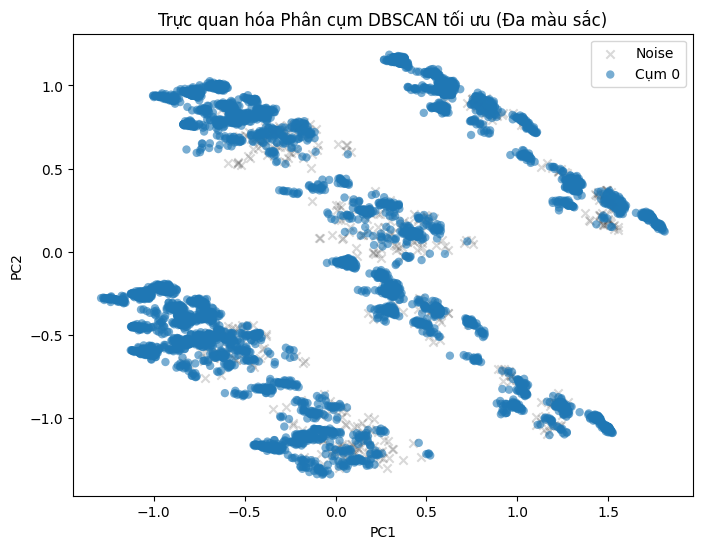

In [47]:
best_dbscan = DBSCANScratch(eps=1.42, min_samples=70)
train_labels_db = best_dbscan.fit_predict(X_train)

unique_db, counts_db = np.unique(train_labels_db, return_counts=True)
# Tự động hóa việc in kích thước tập dữ liệu bằng cách sử dụng thuộc tính shape[0]
print(f'Phân bổ cụm DBSCAN tối ưu trên tập Train đầy đủ ({X_train.shape[0]} mẫu):')
for u, c in zip(unique_db, counts_db):
    if u == -1:
        print(f'  - Nhóm Nhiễu (-1): {c} mẫu')
    else:
        print(f'  - Cụm {u}: {c} mẫu')

# Trực quan hóa ranh giới cụm đa sắc màu trên không gian PCA 2D
plt.figure(figsize=(8, 6))
for label in unique_db:
    idx = np.where(train_labels_db == label)[0]
    if label == -1:
        plt.scatter(X_train_2d[idx, 0], X_train_2d[idx, 1], label='Noise', color='black', alpha=0.15, marker='x')
    else:
        plt.scatter(X_train_2d[idx, 0], X_train_2d[idx, 1], label=f'Cụm {label}', alpha=0.6, edgecolors='none')

plt.title('Trực quan hóa Phân cụm DBSCAN tối ưu (Đa màu sắc)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

## 8. Lưu trữ mô hình

In [48]:
import os
os.makedirs('../models/', exist_ok=True)
with open('../models/dbscan_scratch.pkl', 'wb') as f:
    pickle.dump(best_dbscan, f)
np.save('../models/dbscan_labels.npy', train_labels_db)
print('Đã lưu trữ mô hình DBSCAN và nhãn thành công!')

Đã lưu trữ mô hình DBSCAN và nhãn thành công!
